In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [53]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [54]:
df = pd.read_csv("../data/raw/global_ai_jobs.csv")
df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,Small,7,2020,Remote,44.7,3.67,10,52.765351,0.404,91,3.30,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,Small,3,2021,Onsite,48.9,4.26,27,53.114580,0.387,71,4.39,62.14,13,75.80,28.4,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,Large,3,2020,Remote,46.8,4.78,10,76.395263,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,Large,2,2026,Onsite,52.2,4.34,23,59.340199,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,Medium,2,2021,Hybrid,46.7,4.49,17,72.301128,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72


In [55]:
df["log_salary"] = np.log(df["salary_usd"])

In [56]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (90000, 36)
Columns: ['id', 'country', 'job_role', 'ai_specialization', 'experience_level', 'experience_years', 'salary_usd', 'bonus_usd', 'education_required', 'industry', 'company_size', 'interview_rounds', 'year', 'work_mode', 'weekly_hours', 'company_rating', 'job_openings', 'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score', 'company_funding_billion', 'economic_index', 'ai_maturity_years', 'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days', 'skill_demand_score', 'automation_risk', 'job_security_score', 'career_growth_score', 'work_life_balance_score', 'promotion_speed', 'salary_percentile', 'cost_of_living_index', 'employee_satisfaction', 'log_salary']


In [57]:
X = df.drop(columns=["id", "salary_usd", "log_salary"])
y = df["log_salary"]

In [58]:
X = pd.get_dummies(X, drop_first=True)

In [59]:
X = X.astype(float)

In [60]:
print(X.dtypes.value_counts())
print("Object columns:", X.select_dtypes(include=["object"]).columns.tolist())
print("Encoded feature shape:", X.shape)

float64    72
Name: count, dtype: int64
Object columns: []
Encoded feature shape: (90000, 72)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (72000, 72)
X_test shape : (18000, 72)
y_train shape: (72000,)
y_test shape : (18000,)


In [62]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [63]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Performance")
print(f"R²   : {lr_r2:.4f}")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")

Linear Regression Performance
R²   : 0.9490
MAE  : 0.0905
RMSE : 0.1076


In [64]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [65]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance")
print(f"R²   : {rf_r2:.4f}")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")

Random Forest Performance
R²   : 0.9498
MAE  : 0.0887
RMSE : 0.1068


In [66]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.949042,0.090527,0.107559
1,Random Forest,0.949761,0.088669,0.106798


In [67]:
lr_cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV R² scores:", lr_cv_scores)
print("Mean CV R²:", lr_cv_scores.mean())

Linear Regression CV R² scores: [0.94991467 0.94941629 0.94930205 0.94898161 0.94934593]
Mean CV R²: 0.9493921105967169


In [68]:
rf_cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV R² scores:", rf_cv_scores)
print("Mean CV R²:", rf_cv_scores.mean())

Random Forest CV R² scores: [0.95072159 0.94977555 0.94960428 0.94981559 0.94991778]
Mean CV R²: 0.949966956658604


In [69]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

experience_years               0.452235
country_India                  0.222210
country_Brazil                 0.150837
job_role_Data Analyst          0.060923
bonus_usd                      0.027773
country_USA                    0.021427
country_Singapore              0.004971
job_role_Research Scientist    0.004217
employee_satisfaction          0.003611
country_UAE                    0.002195
layoff_risk                    0.002129
economic_index                 0.002120
offer_acceptance_rate          0.002109
hiring_difficulty_score        0.002052
company_funding_billion        0.002009
dtype: float64

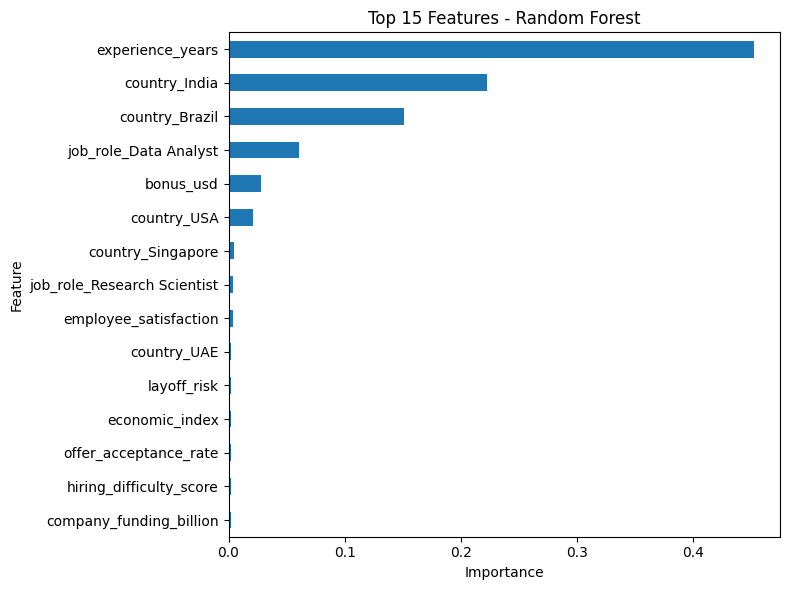

In [70]:
top_15 = feature_importance.head(15).sort_values()

plt.figure(figsize=(8, 6))
top_15.plot(kind="barh")
plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [71]:
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)

In [72]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

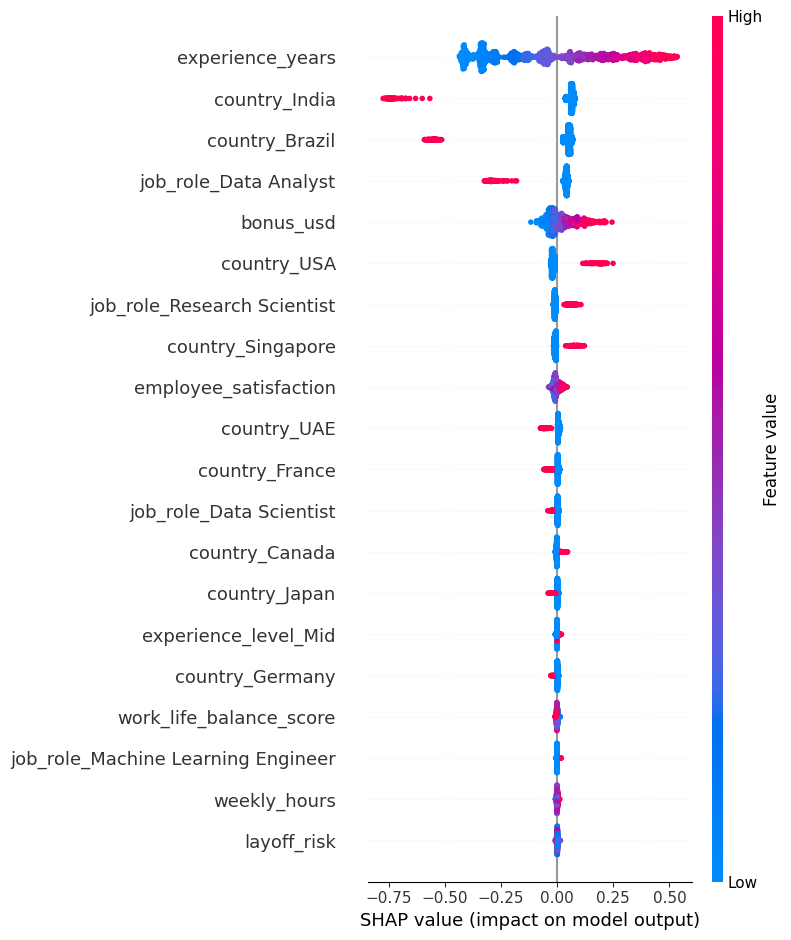

In [73]:
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

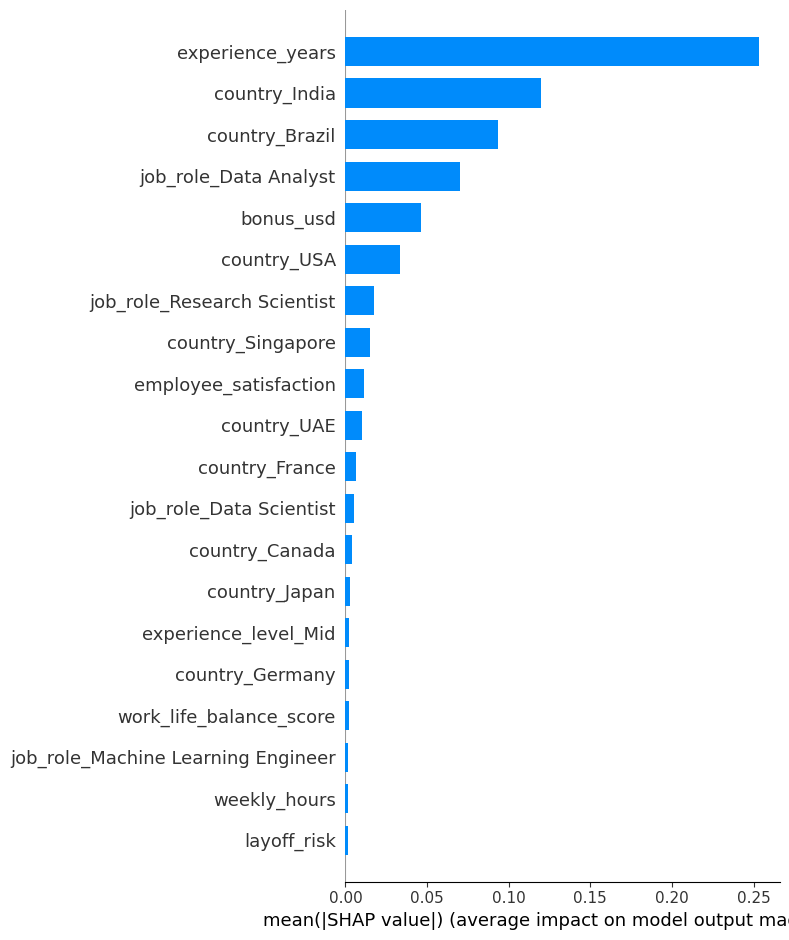

In [74]:
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

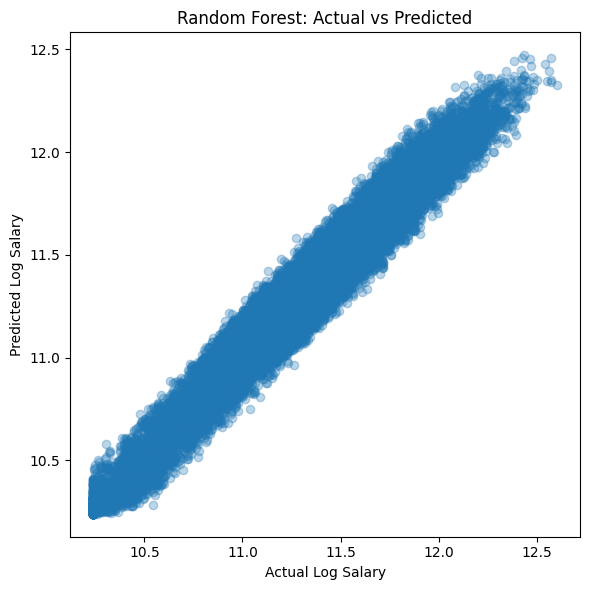

In [75]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Log Salary")
plt.ylabel("Predicted Log Salary")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.savefig("../outputs/figures/rf_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()